In [3]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
from getdist import plots, MCSamples
import getdist
import camb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython
print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))

GetDist Version: 1.5.4, Matplotlib version: 3.9.2


In [4]:
# Loading samples
#w0wacdm: ACT, PLANCK, DESIDR2, DESY5
#chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/planckcut_all', 'w0wacdm')
chain_act = '/home/andrewcats/tesi_magistrale/lcdm/act_planck/act_planck'
samples_act = getdist.mcsamples.loadMCSamples(file_root=chain_act, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_act = [param.name for param in samples_act.paramNames.names]
print(param_names_act)

chain_desidr2 = '/home/andrewcats/tesi_magistrale/lcdm/desidr2/1_lcdm_desidr2'
samples_desidr2 = getdist.mcsamples.loadMCSamples(file_root=chain_desidr2, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_desidr2 = [param.name for param in samples_desidr2.paramNames.names]
print(param_names_desidr2)

chain_desidr1 = '/home/andrewcats/tesi_magistrale/lcdm/desidr1/desidr1'
samples_desidr1 = getdist.mcsamples.loadMCSamples(file_root=chain_desidr1, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_desidr1 = [param.name for param in samples_desidr1.paramNames.names]
print(param_names_desidr1)

['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'A_act', 'P_act', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'A_planck', 'chi2__CMB', 'chi2', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE_sroll2', 'chi2__act_dr6_cmbonly.PlanckActCut', 'chi2__act_dr6_cmbonly']
['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'chi2__BAO', 'chi2', 'chi2__bao.desi_dr2.desi_bao_all']
/home/andrewcats/tesi_magistrale/lcdm/desidr1/desidr1.1.txt
/home/andrewcats/tesi_magistrale/lcdm/desidr1/desidr1.2.txt
/home/andrewcats/tesi_magistrale/lcdm/desidr1/desidr1.3.txt
/home/andrewcats/tesi_magistrale/lcdm/desidr1/desidr1.4.txt
Removed 0.3 as burn in
['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A', 'As', '

"\ng1 = plots.get_subplot_plotter()\ng1.triangle_plot(samples, ['H0', 'ombh2', 'omch2', 'ns'], filled=True)\ng1.add_legend(['LCDM', 'w0wa'])\n"

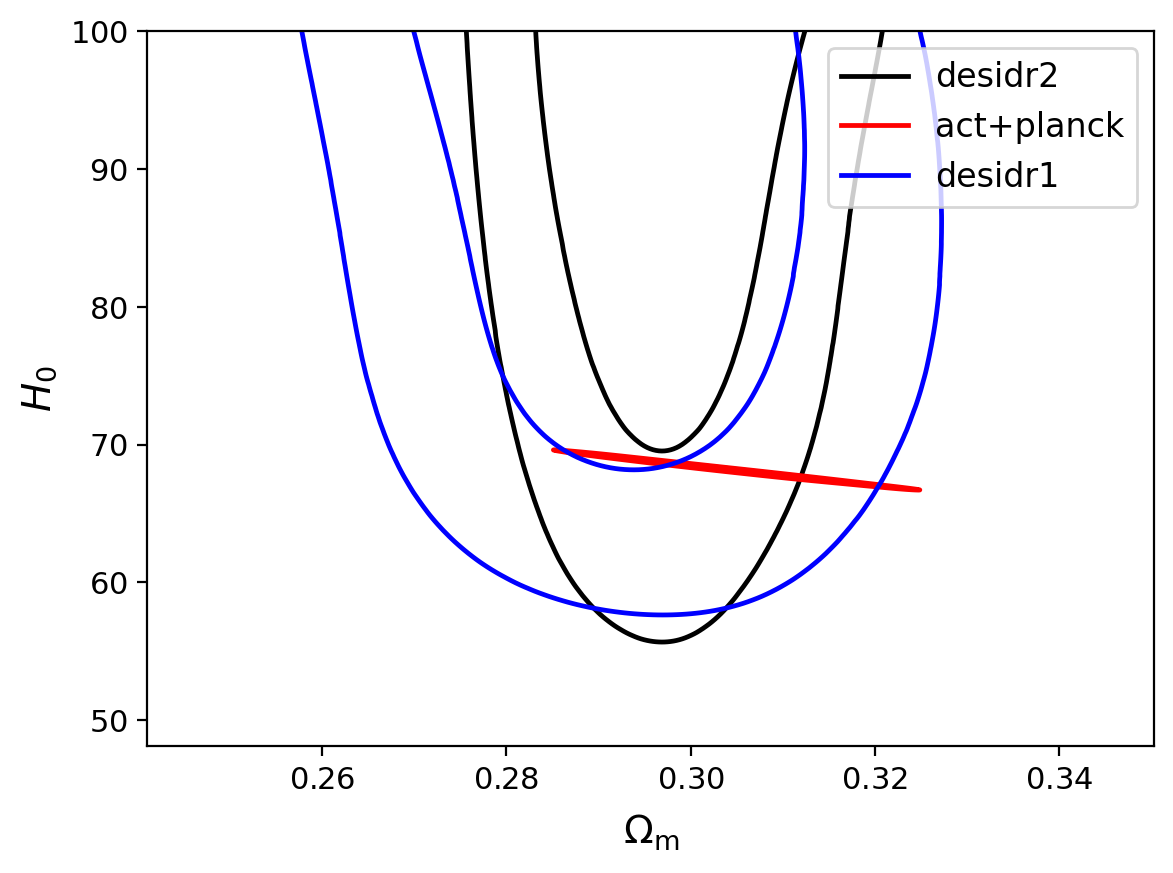

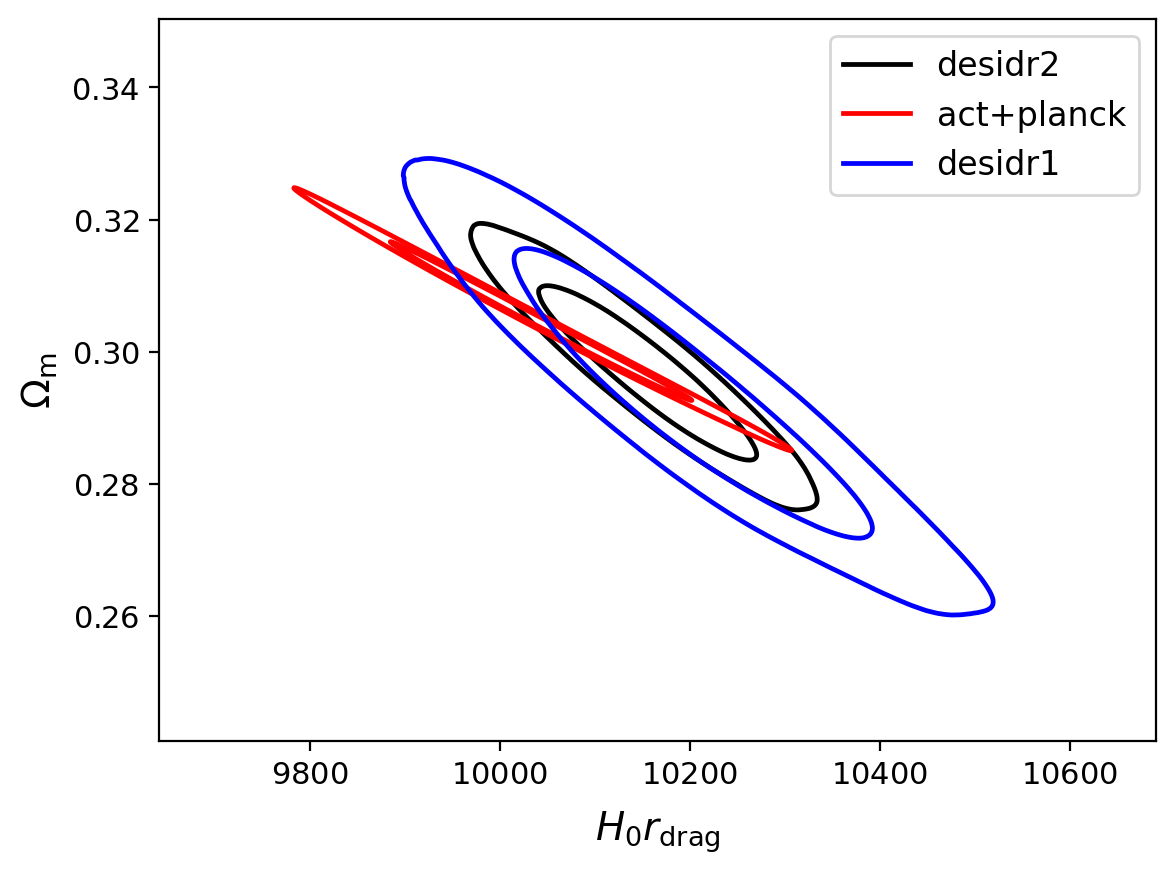

In [5]:
# Comparing 3 samples in the same plot
# lcdm vs w0wa
samples = [samples_desidr2, samples_act, samples_desidr1]
g = plots.get_single_plotter()
g.plot_2d(samples, ['omegam', 'H0'])
g.add_legend(['desidr2', 'act+planck', 'desidr1'])

h0_samples_desidr2 = samples_desidr2.samples[:, samples_desidr2.index['H0']]
rdrag_samples_desidr2 = samples_desidr2.samples[:, samples_desidr2.index['rdrag']]
h0rdrag_desidr2 = h0_samples_desidr2 * rdrag_samples_desidr2

h0_samples_act = samples_act.samples[:, samples_act.index['H0']]
rdrag_samples_act = samples_act.samples[:, samples_act.index['rdrag']]
h0rdrag_act = h0_samples_act * rdrag_samples_act

h0_samples_desidr1 = samples_desidr1.samples[:, samples_desidr1.index['H0']]
rdrag_samples_desidr1 = samples_desidr1.samples[:, samples_desidr1.index['rdrag']]
h0rdrag_desidr1 = h0_samples_desidr1 * rdrag_samples_desidr1

# Add it as a derived parameter
samples_desidr2.addDerived(h0rdrag_desidr2, name='H0rdrag', label='H_0 r_\mathrm{drag}')
samples_act.addDerived(h0rdrag_act, name='H0rdrag', label='H_0 r_\mathrm{drag}')
samples_desidr1.addDerived(h0rdrag_desidr1, name='H0rdrag', label='H_0 r_\mathrm{drag}')



samples = [samples_desidr2, samples_act, samples_desidr1]
g = plots.get_single_plotter()
g.plot_2d(samples, [ 'H0rdrag', 'omegam'])
g.add_legend(['desidr2', 'act+planck', 'desidr1'])

'''
g1 = plots.get_subplot_plotter()
g1.triangle_plot(samples, ['H0', 'ombh2', 'omch2', 'ns'], filled=True)
g1.add_legend(['LCDM', 'w0wa'])
'''